Summary

This notebook explores the Telco Customer Churn dataset (~7,000 customers) 
to identify patterns behind why customers leave.

Data Loading & Cleaning

In [129]:
import pandas as pd

df = pd.read_csv('../data/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [131]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [132]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [133]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [134]:
df['TotalCharges'].dtype

dtype('O')

In [135]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [136]:
df['TotalCharges'].dtype

dtype('O')

Univariate EDA

In [137]:
import matplotlib.pyplot as plt

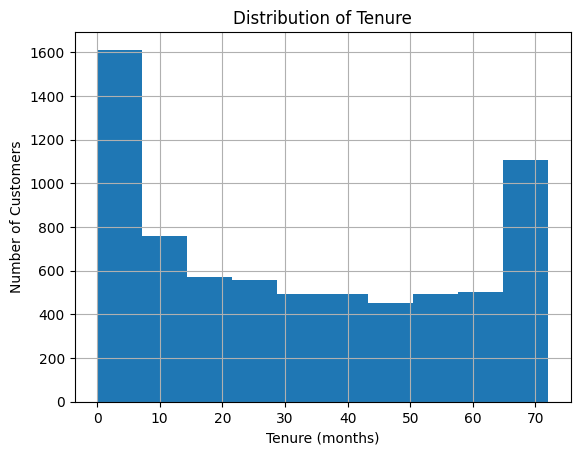

In [138]:
#Histogram of Tenure
df['tenure'].hist()
plt.title('Distribution of Tenure')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

Most customers are either very new (0-6 months) or have been with the company a long time (65-72 months), with fewer customers in between. This could mean a lot of customers leave early on, while the ones who stick around tend to stay for years.

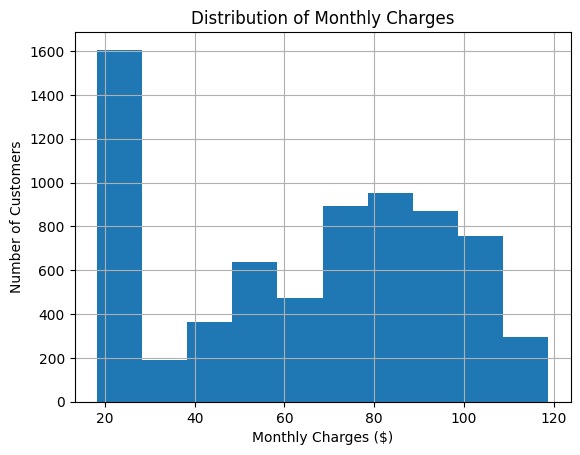

In [139]:
#Histogram for Monthly Charges 
df['MonthlyCharges'].hist()
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.show()

There's a huge spike of over 1,600 customers paying around $20 a month, likely people with just basic service like phone-only plans. After that, the numbers dip and then rise again, peaking around $80-90 a month, which is probably customers with bundled services like internet and streaming.

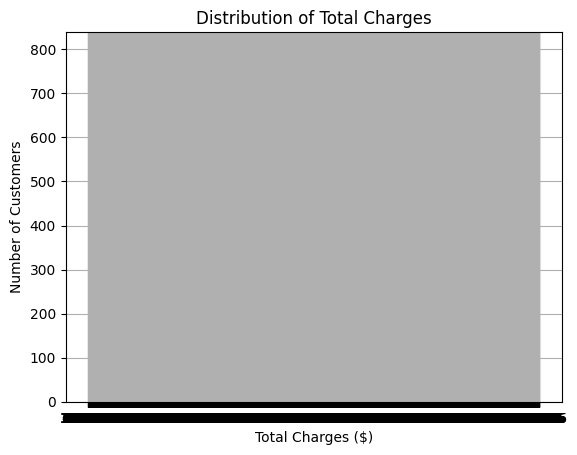

In [140]:
#Histogram for Total Charges
df['TotalCharges'].hist()
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges ($)')
plt.ylabel('Number of Customers')
plt.show()

There's a big spike of over 2,600 customers with total charges under $800, probably people who are newer customers and haven't been billed much yet. After that the numbers drop off and slowly decrease, with just a few customers all the way out at $8,000+ who've probably been with the company a long time.

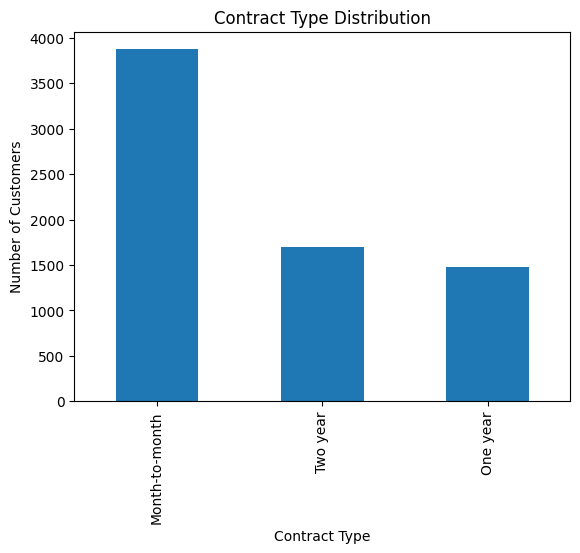

In [141]:
#Bar Chart for Contract Type 
df['Contract'].value_counts().plot(kind='bar')
plt.title('Contract Type Distribution')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

Most customers are on month-to-month contracts, with far fewer on one-year or two-year contracts. This could be important for churn, since month-to-month customers can leave anytime without a penalty.

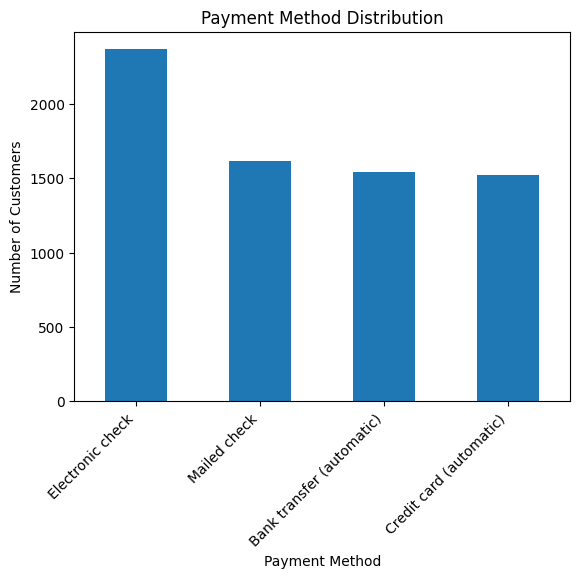

In [142]:
#Bar Chart for Payment Method 
df['PaymentMethod'].value_counts().plot(kind='bar')
plt.xticks(rotation=45, ha='right')
plt.title('Payment Method Distribution')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.show()

Electronic check appears to be the most common payment method, followed by the other three options which look fairly similar in size. It might be worth checking later if electronic check users churn more than customers using automatic payments.

Bivariate EDA (Comparing Features to Churn)

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/telco_churn.csv')

#check
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

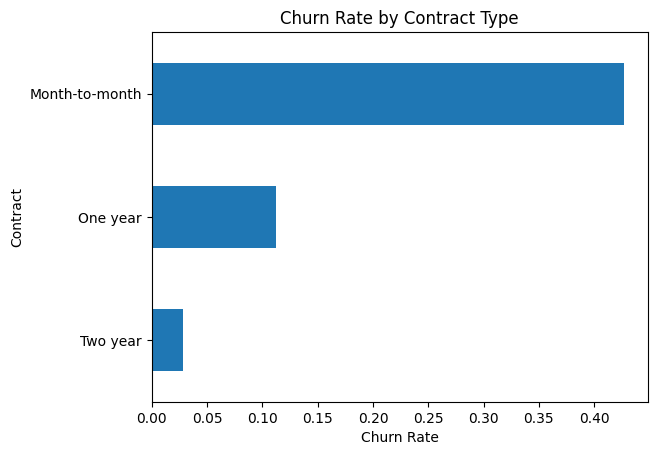

In [144]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')['Yes'].sort_values().plot(kind='barh')
plt.xlabel('Churn Rate')
plt.title('Churn Rate by Contract Type')
plt.show()


--- PaymentMethod ---
PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Yes, dtype: float64

--- InternetService ---
InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Yes, dtype: float64

--- gender ---
gender
Female    0.269209
Male      0.261603
Name: Yes, dtype: float64

--- SeniorCitizen ---
SeniorCitizen
1    0.416813
0    0.236062
Name: Yes, dtype: float64

--- Partner ---
Partner
No     0.329580
Yes    0.196649
Name: Yes, dtype: float64

--- Dependents ---
Dependents
No     0.312791
Yes    0.154502
Name: Yes, dtype: float64

--- TechSupport ---
TechSupport
No                     0.416355
Yes                    0.151663
No internet service    0.074050
Name: Yes, dtype: float64

--- OnlineSecurity ---
OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: 

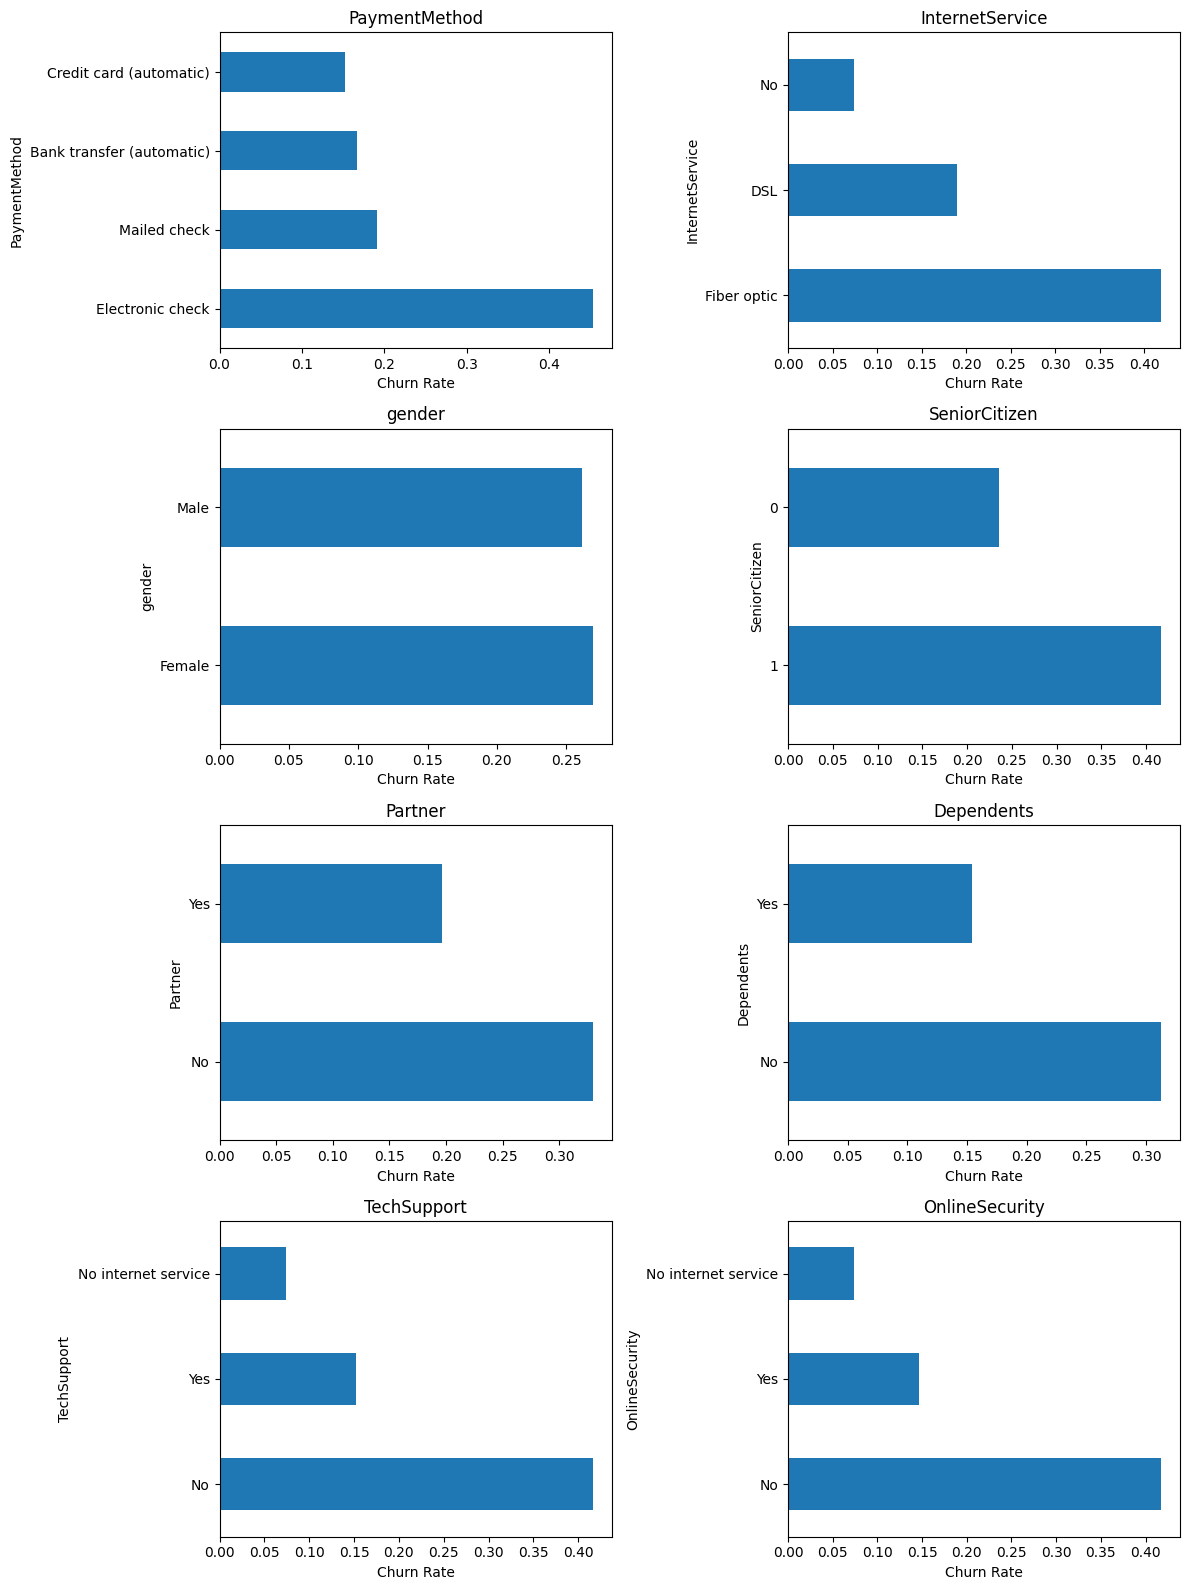

In [145]:
categorical_cols = ['PaymentMethod', 'InternetService', 'gender', 'SeniorCitizen',
                     'Partner', 'Dependents', 'TechSupport', 'OnlineSecurity']

for col in categorical_cols:
    rates = pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'].sort_values(ascending=False)
    print(f"\n--- {col} ---")
    print(rates)

import os
os.makedirs('outputs', exist_ok=True)
fig, axes = plt.subplots(4, 2, figsize=(12, 16))
for ax, col in zip(axes.flatten(), categorical_cols):
    rates = pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'].sort_values(ascending=False)
    rates.plot(kind='barh', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Churn Rate')
plt.tight_layout()
plt.savefig('outputs/categorical_churn_rates.png', dpi=150)
plt.show()

In [146]:
df['StreamingTV']

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040     No
7041     No
7042    Yes
Name: StreamingTV, Length: 7043, dtype: object

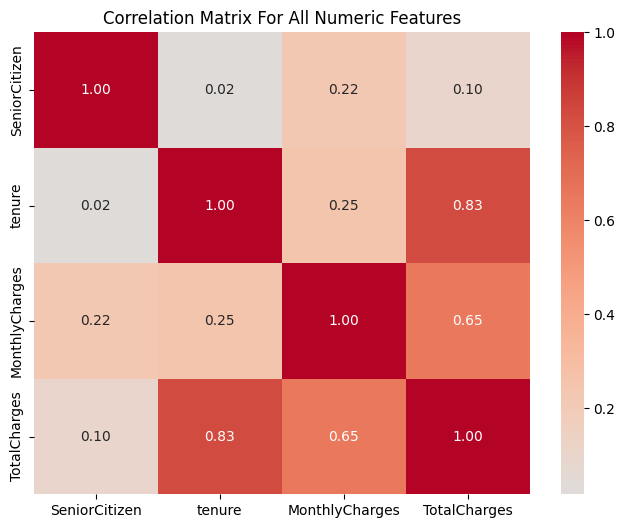

In [147]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df_numeric = df.copy()
df_numeric['Churn_numeric'] = df_numeric['Churn'].map({'Yes': 1, 'No': 0})

#all numeric columns straight from df
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix For All Numeric Features')
plt.savefig('outputs/correlation_heatmap.png', dpi=150)
plt.show()

Bivariate EDA Results

Based on churn rate breakdowns and the correlation heatmap, the strongest predictors of churn are: (more correlated w label)
1. Tenure(-0.35 correlation) — newer customers churn more than 
   long-tenured ones
2. TotalCharges (-0.20 correlation) — customers with lower lifetime 
   spend (often newer customers) churn more
3. MonthlyCharges (0.19 correlation) — higher monthly bills are mildly 
   associated with higher churn
4. Churn - it's the label

Preparing Data for Modeling

In [148]:
# Convert TotalCharges from text to numeric, blanks become a non-number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#all NaNs become 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm it worked
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull().sum()) # should say 0

float64
0


In [149]:
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges


In [150]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [151]:
df = df.drop(columns=['customerID'])
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [152]:
# Convert Churn to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [153]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [154]:
print(df.shape)
print(df.dtypes.value_counts())

(7043, 20)
object     15
int64       3
float64     2
Name: count, dtype: int64


Baseline Model — Logistic Regression

In [155]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                     'MultipleLines', 'InternetService', 'OnlineSecurity',
                     'OnlineBackup', 'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies', 'Contract',
                     'PaperlessBilling', 'PaymentMethod']

# Only encode columns that are still text, skips ones already converted
cols_to_encode = [c for c in categorical_cols if c in df.columns and df[c].dtype == 'object']

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print(df.dtypes.value_counts())  # object should now be 0 (or not listed)

bool       26
int64       3
float64     2
Name: count, dtype: int64


In [156]:
#x is features and y is the label
X = df.drop(columns=['Churn'])
y = df['Churn']

#checks to make sure it's even
print(X.shape, y.shape)

(7043, 30) (7043,)


In [157]:
# imports the function that splits data into train and test sets
from sklearn.model_selection import train_test_split

In [158]:
#split into training data (used to teach the model) and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)

#confirm the split kept the same churn ratio in both halves
print(X_train.shape, X_test.shape)
#both of these should show roughly the same split
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(4930, 30) (2113, 30)
Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64
Churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64


In [159]:
#import train data
from sklearn.linear_model import LogisticRegression
#set up the model with imbalance handling built in, class_weight='balanced' tells the model to pay extra attention to
#mistakes in churned customers since they're rarer in the data and have been converted
#random_state=42 is for reproducibility
#max_iter=5000 gives the model enough iterations to finish training effectively
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=5000)

In [160]:
#train the model on the training data
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [161]:
#generate predictions on the test set
#running predict checks whether what it learned actually generalizes to new customers or if it just memorizes the training data
y_pred = model.predict(X_test)

#check on what the model actually predicted, ideally a mix of 0 and 1
print("Predicted stayed:", sum(y_pred == 0))
print("Predicted churned:", sum(y_pred == 1))

Predicted stayed: 1239
Predicted churned: 874


In [166]:
#gives probability (not just 0/1 predictions)
# returns two columns for probability of "stayed" and probability of "churned" but [:,1] is for churned only
y_pred_proba = model.predict_proba(X_test)[:, 1]
print (y_pred_proba)

[0.7960785  0.08138804 0.89237254 ... 0.10557277 0.78371847 0.08822291]


In [167]:
#gives a full report with accuracy, precision, recall, and F1 all at once
#recall is did I catch the people who actually churned? (correctly predicted churners) / (all actual churners)
#precision is when I said churn, was I right? (correctly predicted churners) / (all predicted churners)
#gives you everything for both classes, stayed and churned
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1552
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113



In [168]:
# Compute ROC-AUC specifically to measure how well the model ranks churners above non-churners using probability rather than 0/1 predictions
#1.0 is perfect, 0.5 is no better than random guessing
from sklearn.metrics import roc_auc_score
auc_score = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", auc_score)

ROC-AUC: 0.8445757989231307


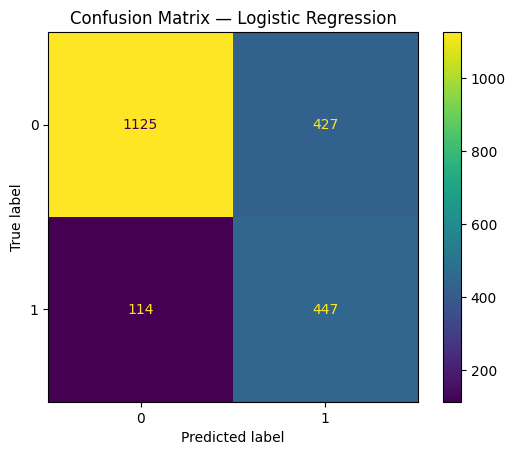

In [170]:
#plot the confusion matrix showing correct vs. incorrect predictions for customers correctly predicted to stay, churn, and mixed up
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix — Logistic Regression')
plt.show()

Correction Matrix: 
- Correctly predicted 1,125 stayed and 447 churned
- Missed 114 actual churners (false negatives) and wrongly flagged 427 
  customers who stayed (false positives)
- Caught ~80% of real churners overall

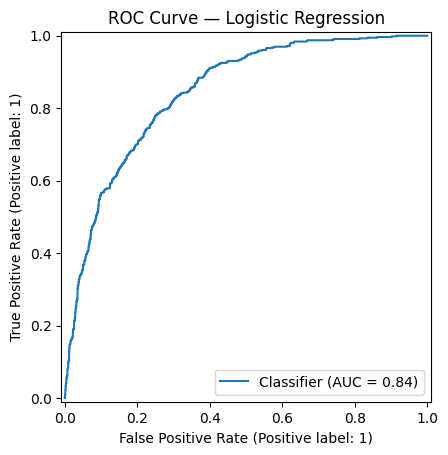

In [171]:
#ROC curve
#goes up toward top-left corner means model is good at identifying churners vs staying, straight diagonal means no better than guess
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_proba)
plt.title('ROC Curve — Logistic Regression')
plt.show()

ROC Curve
- ROC-AUC = 0.84
- pretty accurate, above 0.5 (random guessing)
- curve tilts toward the top-left, showing the model ranks churners above non-churners well

In [172]:
#import cross-validation tool
from sklearn.model_selection import cross_val_score

In [175]:
#run 5-fold cross-validation
#splits the data into 5 equal chunks to train/test the model 5 times w one as test and 4 as training
#checks whether the model's good performance was real or just lucky
#x, y is to use the full dataset (not X_train/X_test) since cross-validation does its own internal splitting
#cv=5 is for 5 folds
#scoring='roc_auc' is  to use ROC-AUC as the score for each fold, most reasonable default metric to compare bc of lack of threshold
cv_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')

In [176]:
#print score from each of 5 folds, close numbers = consistent model
print("Scores for each fold:", cv_scores)

Scores for each fold: [0.85861944 0.85862978 0.83312279 0.83806193 0.839205  ]


In [ ]:
#print the average and std of all 5 folds
#mean = overall performance estimate of which is more accurate
#std = how much the scores varied (smaller = more consistent)
print("Average ROC-AUC:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())